Repo card metadata block was not found. Setting CardData to empty.


Dataset: GAIR/LIMR
Splits loaded: ['train']
Total rows: 1389
Unique sources: 1


,source,count,pct,rank
0,math,1389,100.0,1


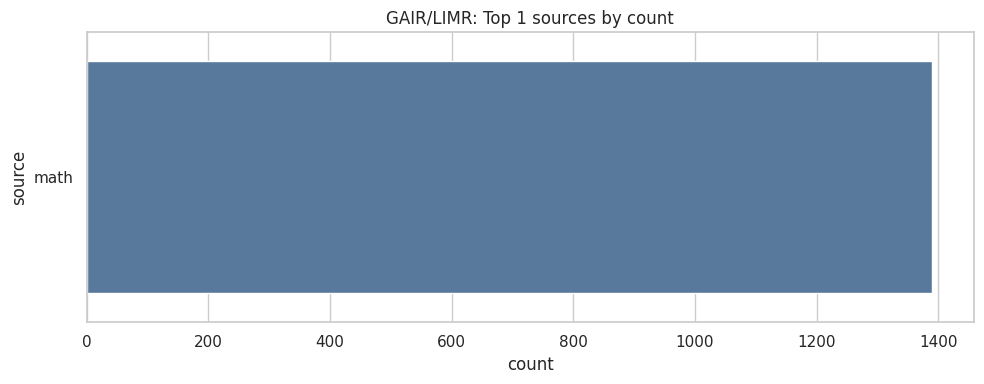

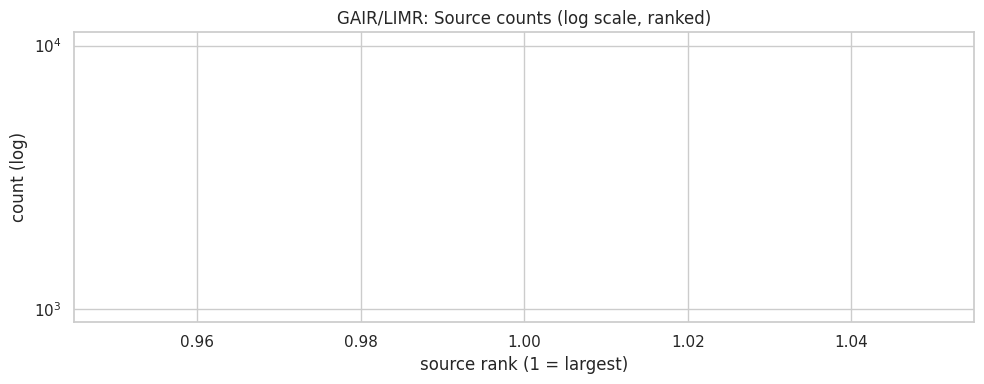

In [13]:
import importlib
import subprocess
import sys
from typing import Optional


def _ensure(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        except Exception as e:
            raise ModuleNotFoundError(
                f"Missing dependency '{import_name}'. Tried to install '{pkg}' via pip but it failed. "
                f"Please install it in this environment (e.g. `pip install {pkg}`) and rerun. Original error: {e}"
            )


_ensure("datasets")
_ensure("pandas")
_ensure("matplotlib")
_ensure("seaborn")

from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):
        print(x)

DATASET_NAME = "GAIR/LIMR"
SOURCE_COL = "source"
TOP_N = 25

# Load dataset (handles DatasetDict vs Dataset)
ds = load_dataset(DATASET_NAME)
if hasattr(ds, "keys"):
    splits = list(ds.keys())
    dsets = [ds[s] for s in splits]
    d_all = pd.concat([d.to_pandas() for d in dsets], ignore_index=True)
else:
    splits = ["(single)"]
    d_all = ds.to_pandas()

if SOURCE_COL not in d_all.columns:
    raise KeyError(
        f"Expected column '{SOURCE_COL}' not found. Available columns: {list(d_all.columns)}"
    )

# Basic stats
n_rows = len(d_all)
source_counts = (
    d_all[SOURCE_COL]
    .fillna("(missing)")
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("source")
    .reset_index(name="count")
)
source_counts["pct"] = source_counts["count"] / n_rows * 100
source_counts["rank"] = range(1, len(source_counts) + 1)

print(f"Dataset: {DATASET_NAME}")
print(f"Splits loaded: {splits}")
print(f"Total rows: {n_rows}")
print(f"Unique sources: {source_counts['source'].nunique()}")

display(source_counts.head(50))

# Visualizations
sns.set_theme(style="whitegrid")

# 1) Top-N sources bar chart
plot_df = source_counts.head(TOP_N).iloc[::-1]  # reverse for horizontal bar
plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
ax = sns.barplot(data=plot_df, x="count", y="source", color="#4C78A8")
ax.set_title(f"{DATASET_NAME}: Top {min(TOP_N, len(source_counts))} sources by count")
ax.set_xlabel("count")
ax.set_ylabel("source")
plt.tight_layout()
plt.show()

# 2) Long-tail view (log scale) for all sources
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=source_counts, x="rank", y="count")
ax.set_yscale("log")
ax.set_title(f"{DATASET_NAME}: Source counts (log scale, ranked)")
ax.set_xlabel("source rank (1 = largest)")
ax.set_ylabel("count (log)")
plt.tight_layout()
plt.show()

# Optional: split-wise breakdown (if multiple splits exist)
if hasattr(ds, "keys") and len(splits) > 1:
    by_split = []
    for s in splits:
        tmp = ds[s].to_pandas()
        tmp[SOURCE_COL] = tmp[SOURCE_COL].fillna("(missing)").astype(str)
        c = tmp[SOURCE_COL].value_counts().rename_axis("source").reset_index(name="count")
        c["split"] = s
        by_split.append(c)
    by_split = pd.concat(by_split, ignore_index=True)
    display(by_split.pivot_table(index="source", columns="split", values="count", fill_value=0))


## GAIR/LIMR — source statistics

This section summarizes:
- **What sources the dataset is from** (unique values in the `source` column)
- **How many examples per source** (counts + percentages)
- **Visualizations** (top sources + long-tail distribution)


## Filter datasets to `source == "numina_amc_aime"` (sample 30)

Loads each dataset in `datasets_to_filter`, filters to rows where `source` matches, and takes a random sample of up to **30** rows.


Dataset: PRIME-RL/Eurus-2-RL-Data
Splits loaded: ['train', 'validation']
Total rows: 482585
Unique sources: 10


,source,count,pct,rank
0,numina_cn_k12,198777,41.190049,1
1,numina_synthetic_math,138025,28.601179,2
2,numina_olympiads,70103,14.526560,3
3,numina_synthetic_amc,34519,7.152937,4
4,numina_aops_forum,12384,2.566180,5
5,codecontests,10016,2.075489,6
6,taco,9961,2.064092,7
7,apps,3604,0.746811,8
8,codeforces,2719,0.563424,9
9,numina_amc_aime,2477,0.513277,10


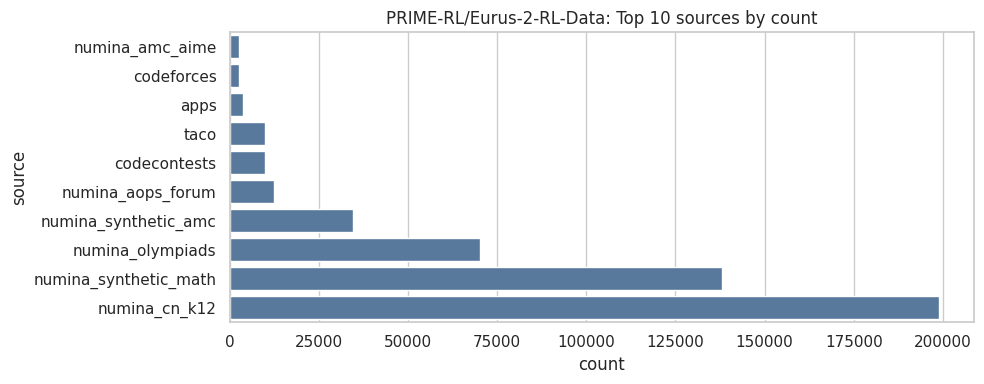

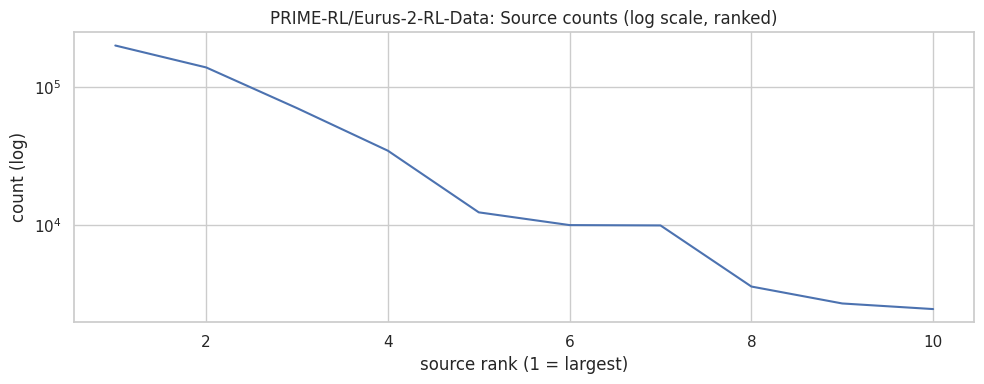

split,train,validation
source,,
apps,3462.0,142.0
codecontests,9639.0,377.0
codeforces,2596.0,123.0
numina_amc_aime,2470.0,7.0
numina_aops_forum,12357.0,27.0
numina_cn_k12,198353.0,424.0
numina_olympiads,69947.0,156.0
numina_synthetic_amc,34447.0,72.0
numina_synthetic_math,137687.0,338.0


In [14]:
import importlib
import subprocess
import sys
from typing import Optional


def _ensure(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        except Exception as e:
            raise ModuleNotFoundError(
                f"Missing dependency '{import_name}'. Tried to install '{pkg}' via pip but it failed. "
                f"Please install it in this environment (e.g. `pip install {pkg}`) and rerun. Original error: {e}"
            )


_ensure("datasets")
_ensure("pandas")
_ensure("matplotlib")
_ensure("seaborn")

from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):
        print(x)

DATASET_NAME = "PRIME-RL/Eurus-2-RL-Data"
SOURCE_COL = "data_source"
TOP_N = 25

# Load dataset (handles DatasetDict vs Dataset)
ds = load_dataset(DATASET_NAME)
if hasattr(ds, "keys"):
    splits = list(ds.keys())
    dsets = [ds[s] for s in splits]
    d_all = pd.concat([d.to_pandas() for d in dsets], ignore_index=True)
else:
    splits = ["(single)"]
    d_all = ds.to_pandas()

if SOURCE_COL not in d_all.columns:
    raise KeyError(
        f"Expected column '{SOURCE_COL}' not found. Available columns: {list(d_all.columns)}"
    )

# Basic stats
n_rows = len(d_all)
source_counts = (
    d_all[SOURCE_COL]
    .fillna("(missing)")
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("source")
    .reset_index(name="count")
)
source_counts["pct"] = source_counts["count"] / n_rows * 100
source_counts["rank"] = range(1, len(source_counts) + 1)

print(f"Dataset: {DATASET_NAME}")
print(f"Splits loaded: {splits}")
print(f"Total rows: {n_rows}")
print(f"Unique sources: {source_counts['source'].nunique()}")

display(source_counts.head(50))

# Visualizations
sns.set_theme(style="whitegrid")

# 1) Top-N sources bar chart
plot_df = source_counts.head(TOP_N).iloc[::-1]  # reverse for horizontal bar
plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
ax = sns.barplot(data=plot_df, x="count", y="source", color="#4C78A8")
ax.set_title(f"{DATASET_NAME}: Top {min(TOP_N, len(source_counts))} sources by count")
ax.set_xlabel("count")
ax.set_ylabel("source")
plt.tight_layout()
plt.show()

# 2) Long-tail view (log scale) for all sources
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=source_counts, x="rank", y="count")
ax.set_yscale("log")
ax.set_title(f"{DATASET_NAME}: Source counts (log scale, ranked)")
ax.set_xlabel("source rank (1 = largest)")
ax.set_ylabel("count (log)")
plt.tight_layout()
plt.show()

# Optional: split-wise breakdown (if multiple splits exist)
if hasattr(ds, "keys") and len(splits) > 1:
    by_split = []
    for s in splits:
        tmp = ds[s].to_pandas()
        tmp[SOURCE_COL] = tmp[SOURCE_COL].fillna("(missing)").astype(str)
        c = tmp[SOURCE_COL].value_counts().rename_axis("source").reset_index(name="count")
        c["split"] = s
        by_split.append(c)
    by_split = pd.concat(by_split, ignore_index=True)
    display(by_split.pivot_table(index="source", columns="split", values="count", fill_value=0))


## PRIME_RL/EURUS — source statistics

This section summarizes:
- **What sources the dataset is from** (unique values in the `source` column)
- **How many examples per source** (counts + percentages)
- **Visualizations** (top sources + long-tail distribution)


In [15]:
import importlib
import subprocess
import sys
from pathlib import Path
from typing import List, Optional

import pandas as pd

try:
    from IPython.display import display  # type: ignore
except Exception:

    def display(x):
        print(x)


def _ensure(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


_ensure("datasets")
_ensure("pandas")
_ensure("pyarrow")  # pandas parquet engine

from datasets import concatenate_datasets, load_dataset

HF_NAME = "PRIME-RL/Eurus-2-RL-Data"
TARGET_SOURCE = "numina_amc_aime"
SAMPLE_N = 30
SEED = 0

# Write under the repo's `benchmarks/` directory whether cwd is repo-root or `benchmarks/`
BASE_DIR = Path(".")
if not (BASE_DIR / "filter_benchmark.ipynb").exists():
    BASE_DIR = Path("benchmarks")

OUT_DIR = BASE_DIR / "filtered_samples"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def _pick_source_col(cols: List[str]) -> str:
    if "source" in cols:
        return "source"
    if "data_source" in cols:
        return "data_source"
    for c in cols:
        if "source" in c.lower():
            return c
    raise KeyError(f"No source-like column found. Available columns: {cols}")


ds = load_dataset(HF_NAME)
splits = list(ds.keys()) if hasattr(ds, "keys") else ["(single)"]

filtered_parts = []
source_col = None
for s in splits:
    d = ds[s] if s != "(single)" else ds
    source_col = _pick_source_col(d.column_names)

    d_match = d.filter(lambda ex, sc=source_col: (ex.get(sc) or "") == TARGET_SOURCE)
    if len(d_match) == 0:
        continue

    if "split" not in d_match.column_names:
        d_match = d_match.add_column("split", [s] * len(d_match))
    filtered_parts.append(d_match)

if not filtered_parts:
    eurus_numina_amc_aime = None
    eurus_numina_amc_aime_30 = None
    summary_df = pd.DataFrame(
        [
            {
                "dataset": HF_NAME,
                "splits": splits,
                "source_col": source_col,
                "target_source": TARGET_SOURCE,
                "matches": 0,
                "sampled": 0,
                "status": "ok (no matches)",
            }
        ]
    )
    display(summary_df)
else:
    eurus_numina_amc_aime = (
        concatenate_datasets(filtered_parts)
        if len(filtered_parts) > 1
        else filtered_parts[0]
    )
    n_match = len(eurus_numina_amc_aime)
    eurus_numina_amc_aime_30 = eurus_numina_amc_aime.shuffle(seed=SEED).select(
        range(min(SAMPLE_N, n_match))
    )

    summary_df = pd.DataFrame(
        [
            {
                "dataset": HF_NAME,
                "splits": splits,
                "source_col": source_col,
                "target_source": TARGET_SOURCE,
                "matches": n_match,
                "sampled": len(eurus_numina_amc_aime_30),
                "status": "ok",
            }
        ]
    )
    display(summary_df)

    out_stem = "PRIME-RL__Eurus-2-RL-Data__numina_amc_aime__sample30"
    out_parquet = OUT_DIR / f"{out_stem}.parquet"

    df30 = eurus_numina_amc_aime_30.to_pandas()

    # Keep only `data_source` + `prompt` + extracted answer from `reward_model.ground_truth`
    if "prompt" not in df30.columns:
        raise KeyError(
            f"Expected column 'prompt' not found. Available columns: {list(df30.columns)}"
        )

    if "data_source" not in df30.columns:
        if source_col and source_col in df30.columns:
            df30["data_source"] = df30[source_col]
        else:
            raise KeyError(
                f"Expected column 'data_source' (or source_col='{source_col}') not found. "
                f"Available columns: {list(df30.columns)}"
            )

    if "reward_model" not in df30.columns:
        raise KeyError(
            f"Expected column 'reward_model' not found. Available columns: {list(df30.columns)}"
        )

    import ast
    import json

    def _extract_reward_ground_truth(v):
        if v is None:
            return None

        # Convert numpy scalars / arrays to Python types if present
        if hasattr(v, "tolist") and not isinstance(v, (str, bytes, dict, list, tuple)):
            try:
                v = v.tolist()
            except Exception:
                pass

        # If serialized as string, try to parse into dict
        if isinstance(v, str):
            s = v.strip()
            parsed = None
            for loader in (json.loads, ast.literal_eval):
                try:
                    parsed = loader(s)
                    break
                except Exception:
                    continue
            if parsed is not None:
                v = parsed
            else:
                # fallback: treat the string itself as the ground truth
                return s if s else None

        # Sometimes stored as list[dict]
        if isinstance(v, (list, tuple)) and v:
            v0 = v[0]
            if isinstance(v0, dict):
                v = v0

        if isinstance(v, dict):
            gt = v.get("ground_truth")
            if gt is None:
                gt = v.get("groundTruth")
            if gt is None:
                return None
            s = str(gt).strip()
            return s if s else None

        # Unknown type
        return None

    df30["answer"] = df30["reward_model"].map(_extract_reward_ground_truth)

    df30 = df30[["data_source", "prompt", "answer"]].copy()

    df30.to_parquet(out_parquet, index=False)

    print(f"Wrote: {out_parquet}")
    display(df30)

    # --- Upload to Hugging Face Hub ---
    _ensure("huggingface_hub")
    import os

    from huggingface_hub import HfApi, HfFolder

    HF_REPO_ID = "talzoomanzoo/Eurus-2-RL-Data-amc-aime"
    HF_REPO_TYPE = "dataset"

    token = HfFolder.get_token() or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")
    if not token:
        raise RuntimeError(
            "Hugging Face token not found. Run `huggingface-cli login` in this environment, "
            "or set `HF_TOKEN` (or `HUGGINGFACE_TOKEN`) and re-run the cell."
        )

    api = HfApi(token=token)
    api.create_repo(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE, exist_ok=True)

    # Ensure the repo only contains THIS parquet (otherwise load_dataset() shows >30 rows)
    existing_files = api.list_repo_files(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE)
    for f in existing_files:
        if f.endswith(".parquet") and f != out_parquet.name:
            api.delete_file(
                path_in_repo=f,
                repo_id=HF_REPO_ID,
                repo_type=HF_REPO_TYPE,
                commit_message=f"Remove {f} (keep only sample30)",
            )
            print(f"Deleted from repo: {f}")

    uploaded_url = api.upload_file(
        path_or_fileobj=str(out_parquet),
        path_in_repo=out_parquet.name,
        repo_id=HF_REPO_ID,
        repo_type=HF_REPO_TYPE,
        commit_message=f"Add {out_parquet.name}",
    )
    print(f"Uploaded to: {uploaded_url}")


,dataset,splits,source_col,target_source,matches,sampled,status
0,PRIME-RL/Eurus-2-RL-Data,"[train, validation]",data_source,numina_amc_aime,2477,30,ok


Wrote: filtered_samples/PRIME-RL__Eurus-2-RL-Data__numina_amc_aime__sample30.parquet


,data_source,prompt,answer
0,numina_amc_aime,[{'content': ' When tackling complex reasoning...,134
1,numina_amc_aime,[{'content': ' When tackling complex reasoning...,8
2,numina_amc_aime,[{'content': ' When tackling complex reasoning...,7350
3,numina_amc_aime,[{'content': ' When tackling complex reasoning...,64
4,numina_amc_aime,[{'content': ' When tackling complex reasoning...,991
5,numina_amc_aime,[{'content': ' When tackling complex reasoning...,132
6,numina_amc_aime,[{'content': ' When tackling complex reasoning...,y + 3x - 4 = 0
7,numina_amc_aime,[{'content': ' When tackling complex reasoning...,17
8,numina_amc_aime,[{'content': ' When tackling complex reasoning...,2
9,numina_amc_aime,[{'content': ' When tackling complex reasoning...,5


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 7.98kB / 7.98kB,   ???B/s  




Processing Files (1 / 1)                : 100%|██████████| 7.98kB / 7.98kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...__numina_amc_aime__sample30.parquet: 100%|██████████| 7.98kB / 7.98kB            


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/Eurus-2-RL-Data-amc-aime/blob/main/PRIME-RL__Eurus-2-RL-Data__numina_amc_aime__sample30.parquet


In [16]:
import os
from pathlib import Path
from typing import Optional

import pandas as pd

# Ensure dependencies (safe even if already installed)
import importlib
import subprocess
import sys


def _ensure(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


def _norm_answer(x) -> Optional[str]:
    if x is None:
        return None
    s = str(x).strip()
    return s if s else None


_ensure("datasets")
_ensure("pandas")
_ensure("pyarrow")

from datasets import concatenate_datasets, load_dataset

# Avoid hf_transfer requirement if enabled in env
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

try:
    from IPython.display import display  # type: ignore
except Exception:

    def display(x):
        print(x)


# ----- Read system prompt template from an existing parquet with `prompt` -----
# Resolve `filtered_samples/` robustly regardless of whether cwd is repo-root or `benchmarks/`.
FILTERED_DIR_CANDIDATES = [Path("filtered_samples"), Path("benchmarks") / "filtered_samples"]
FILTERED_DIR = next((p for p in FILTERED_DIR_CANDIDATES if p.exists()), FILTERED_DIR_CANDIDATES[0])
FILTERED_DIR.mkdir(parents=True, exist_ok=True)

# Use the Eurus 30-sample parquet as the prompt template source (it contains `prompt`).
TEMPLATE_PARQUET_NAME = "PRIME-RL__Eurus-2-RL-Data__numina_amc_aime__sample30.parquet"
TEMPLATE_PARQUET_CANDIDATES = [
    FILTERED_DIR / TEMPLATE_PARQUET_NAME,
    Path("benchmarks") / "filtered_samples" / TEMPLATE_PARQUET_NAME,
]
TEMPLATE_PARQUET = next((p for p in TEMPLATE_PARQUET_CANDIDATES if p.exists()), None)
if TEMPLATE_PARQUET is None:
    raise FileNotFoundError(
        "Can't find a prompt-template parquet. Expected one of: "
        + ", ".join(str(p) for p in TEMPLATE_PARQUET_CANDIDATES)
        + ". Run the Eurus sampling cell first."
    )

def _extract_system_msg_from_prompt_cell(prompt_val) -> str:
    v = prompt_val
    if hasattr(v, "tolist") and not isinstance(v, (str, bytes, dict, list, tuple)):
        try:
            v = v.tolist()
        except Exception:
            pass

    if isinstance(v, dict):
        v = [v]
    elif isinstance(v, tuple):
        v = list(v)

    if not isinstance(v, list) or not v:
        raise TypeError(f"prompt cell is not list-like (got {type(prompt_val)})")

    first = v[0]
    if isinstance(first, dict) and "content" in first:
        return str(first["content"])
    raise TypeError(f"unexpected prompt element type/shape: {type(first)}")


def _try_load_system_msg(template_parquet: Path) -> str:
    df = pd.read_parquet(template_parquet)
    if "prompt" not in df.columns:
        raise KeyError(f"{template_parquet} missing 'prompt' column")
    return _extract_system_msg_from_prompt_cell(df.iloc[0]["prompt"])


template_candidates = [
    FILTERED_DIR / "GAIR__LIMR__math__sample30__aime26_prompt.parquet",
    FILTERED_DIR / "math-ai__aime26__eurus_prompt.parquet",
    FILTERED_DIR / "math-ai__aime26__limr_prompt.parquet",
    FILTERED_DIR / "math-ai__aime26__still_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "GAIR__LIMR__math__sample30__aime26_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "math-ai__aime26__eurus_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "math-ai__aime26__limr_prompt.parquet",
    Path("benchmarks") / "filtered_samples" / "math-ai__aime26__still_prompt.parquet",
]

EURUS_SYSTEM_MSG = None
for cand in template_candidates:
    if not cand.exists():
        continue
    try:
        EURUS_SYSTEM_MSG = _try_load_system_msg(cand)
        break
    except Exception as e:
        print(f"Skipping template {cand} (can't extract system msg): {e}")

if EURUS_SYSTEM_MSG is None:
    EURUS_SYSTEM_MSG = "You are a helpful assistant."
    print("Warning: couldn't find a chat-style template parquet; using fallback system message.")

# ----- Load AIME 2026 dataset and format prompts -----
AIME_NAME = "math-ai/aime26"
DATA_SOURCE = "aime26"


def _pick_problem_col(cols: list[str]) -> str:
    for c in ["problem", "question", "prompt", "statement"]:
        if c in cols:
            return c
    raise KeyError(f"No problem-like column found. Available columns: {cols}")


def _pick_answer_col(cols: list[str]) -> str:
    for c in ["answer", "final_answer", "target", "solution"]:
        if c in cols:
            return c
    raise KeyError(f"No answer-like column found. Available columns: {cols}")


aime = load_dataset(AIME_NAME)
if hasattr(aime, "keys"):
    splits = list(aime.keys())
    parts = [aime[s] for s in splits]
    aime_all = concatenate_datasets(parts) if len(parts) > 1 else parts[0]
else:
    splits = ["(single)"]
    aime_all = aime

problem_col = _pick_problem_col(aime_all.column_names)
answer_col = _pick_answer_col(aime_all.column_names)

rows = []
for ex in aime_all:
    problem = ex.get(problem_col)
    if problem is None:
        continue
    user_content = (
        str(problem).rstrip()
        + "\n\nPresent the answer in LaTex format: \\boxed{Your answer}"
    )
    rows.append(
        {
            "data_source": DATA_SOURCE,
            "prompt": [
                {"role": "system", "content": EURUS_SYSTEM_MSG},
                {"role": "user", "content": user_content},
            ],
            "answer": _norm_answer(ex.get(answer_col)),
        }
    )

aime_df = pd.DataFrame(rows)
print(f"Loaded {AIME_NAME} splits={splits} rows={len(aime_all)}")
print(f"Formatted rows={len(aime_df)}")

OUT_DIR = FILTERED_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_parquet = OUT_DIR / "math-ai__aime26__eurus_prompt.parquet"
aime_df.to_parquet(out_parquet, index=False)
print(f"Wrote: {out_parquet}")

display(aime_df.head(3))

# Optional upload (only if token present)
_ensure("huggingface_hub")
from huggingface_hub import HfApi, HfFolder

token = HfFolder.get_token() or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")
if token:
    api = HfApi(token=token)

    # 1) Upload into your combined repo (same as Eurus pipeline)
    repo_id = "talzoomanzoo/limr-amc-aime"
    api.create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)
    url = api.upload_file(
        path_or_fileobj=str(out_parquet),
        path_in_repo=out_parquet.name,
        repo_id=repo_id,
        repo_type="dataset",
        commit_message=f"Add {out_parquet.name} (aime26)",
    )
    print(f"Uploaded to: {url}")

    # 2) Also upload as its own dataset repo
    repo_id2 = "talzoomanzoo/aime26"
    api.create_repo(repo_id=repo_id2, repo_type="dataset", exist_ok=True)
    url2 = api.upload_file(
        path_or_fileobj=str(out_parquet),
        path_in_repo=out_parquet.name,
        repo_id=repo_id2,
        repo_type="dataset",
        commit_message=f"Add {out_parquet.name}",
    )
    print(f"Uploaded to: {url2}")
else:
    print(
        "No Hugging Face token found (HF_TOKEN/HUGGINGFACE_TOKEN or huggingface-cli login). "
        "Skipping upload."
    )


Loaded math-ai/aime26 splits=['test'] rows=30
Formatted rows=30
Wrote: filtered_samples/math-ai__aime26__eurus_prompt.parquet


,data_source,prompt,answer
0,aime26,"[{'role': 'system', 'content': ' When tackling...",277
1,aime26,"[{'role': 'system', 'content': ' When tackling...",62
2,aime26,"[{'role': 'system', 'content': ' When tackling...",79


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,   ???B/s  

Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...th-ai__aime26__eurus_prompt.parquet: 100%|██████████| 11.6kB / 11.6kB            
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/limr-amc-aime/blob/main/math-ai__aime26__eurus_prompt.parquet


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,   ???B/s  

Processing Files (1 / 1)                : 100%|██████████| 11.6kB / 11.6kB,  0.00B/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...th-ai__aime26__eurus_prompt.parquet: 100%|██████████| 11.6kB / 11.6kB            


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/aime26/blob/main/math-ai__aime26__eurus_prompt.parquet


## Combine HF datasets: `talzoomanzoo/aime26` + `talzoomanzoo/Eurus-2-RL-Data-amc-aime`

Adds a `member` column:
- `talzoomanzoo/aime26` → `member = 0`
- `talzoomanzoo/Eurus-2-RL-Data-amc-aime` → `member = 1`


In [17]:
import os
from pathlib import Path

import pandas as pd

# avoid requiring hf_transfer if set in environment
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

from datasets import concatenate_datasets, load_dataset

AIME_REPO = "talzoomanzoo/aime26"
EURUS_REPO = "talzoomanzoo/Eurus-2-RL-Data-amc-aime"

# Load
aime = load_dataset(AIME_REPO)["train"]
eurus = load_dataset(EURUS_REPO)["train"]

# Add member column
aime = aime.add_column("member", [0] * len(aime))
eurus = eurus.add_column("member", [1] * len(eurus))

combined = concatenate_datasets([aime, eurus])
print("aime rows:", len(aime))
print("eurus rows:", len(eurus))
print("combined rows:", len(combined))
print("combined columns:", combined.column_names)

# Save under benchmarks/
BASE_DIR = Path(".")
if not (BASE_DIR / "filter_benchmark.ipynb").exists():
    BASE_DIR = Path("benchmarks")

OUT_DIR = BASE_DIR / "filtered_samples"
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_parquet = OUT_DIR / "talzoomanzoo__aime26_plus_eurus_amc_aime__with_member.parquet"
df = combined.to_pandas()
df.to_parquet(out_parquet, index=False)
print("Wrote:", out_parquet)

display(df.head(5))

# Upload to Hugging Face as `talzoomanzoo/eurus_member`
import importlib
import subprocess
import sys


def _ensure(import_name: str) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", import_name])


_ensure("huggingface_hub")

from huggingface_hub import HfApi, HfFolder

HF_REPO_ID = "talzoomanzoo/eurus_member"
HF_REPO_TYPE = "dataset"

token = HfFolder.get_token() or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")
if not token:
    raise RuntimeError(
        "Hugging Face token not found. Run `huggingface-cli login` in this environment, "
        "or set `HF_TOKEN` (or `HUGGINGFACE_TOKEN`) and re-run the cell."
    )

api = HfApi(token=token)
api.create_repo(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE, exist_ok=True)

url = api.upload_file(
    path_or_fileobj=str(out_parquet),
    path_in_repo=out_parquet.name,
    repo_id=HF_REPO_ID,
    repo_type=HF_REPO_TYPE,
    commit_message=f"Add {out_parquet.name}",
)
print(f"Uploaded to: {url}")


Generating train split: 30 examples [00:00, 8172.31 examples/s]
Generating train split: 30 examples [00:00, 8469.92 examples/s]

aime rows: 30
eurus rows: 30
combined rows: 60
combined columns: ['data_source', 'prompt', 'answer', 'member']
Wrote: filtered_samples/talzoomanzoo__aime26_plus_eurus_amc_aime__with_member.parquet


,data_source,prompt,answer,member
0,aime26,[{'content': ' When tackling complex reasoning...,277,0
1,aime26,[{'content': ' When tackling complex reasoning...,62,0
2,aime26,[{'content': ' When tackling complex reasoning...,79,0
3,aime26,[{'content': ' When tackling complex reasoning...,70,0
4,aime26,[{'content': ' When tackling complex reasoning...,65,0


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 14.7kB / 14.7kB, 36.7kB/s  

Processing Files (1 / 1)                : 100%|██████████| 14.7kB / 14.7kB, 24.5kB/s  
New Data Upload                         : 100%|██████████| 14.7kB / 14.7kB, 24.5kB/s  
  ...eurus_amc_aime__with_member.parquet: 100%|██████████| 14.7kB / 14.7kB            


Uploaded to: https://huggingface.co/datasets/talzoomanzoo/eurus_member/blob/main/talzoomanzoo__aime26_plus_eurus_amc_aime__with_member.parquet
